In [14]:
import os
os.environ["OMP_NUM_THREADS"] = "6"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [15]:
from sqlalchemy import create_engine
import urllib

# Configura la conexión
server = '192.168.100.73'
database = 'ESPDM'
username = 'ESParking'
password = 'ESP.2026'
driver = 'ODBC Driver 17 for SQL Server'  # Verifica que tengas este driver instalado

params = urllib.parse.quote_plus(
    f'DRIVER={{{driver}}};'
    f'SERVER={server};'
    f'DATABASE={database};'
    f'UID={username};'
    f'PWD={password}'
)


In [16]:

engine = create_engine(f'mssql+pyodbc:///?odbc_connect={params}')

query = "SELECT [plate],[NTrans],[AvgMinutes],[TotalAmount],[LM60]+[LT60]+[LM120]+[LT120] [L120],[LM320]+[LT320] [L320],[LMRest]+[LTRest] [LRest],[F60]+[F120]+[F320]+[FRest] [FT],[Age],[Tag],[DigTrans] FROM [ESPDM].[dbo].[ParkingTransSummaryEnriched] where [IDPK] = 'PKGU' and [NTrans] > 5"

df = pd.read_sql(query, engine)

#print(df.head())


In [17]:
df.describe()

,NTrans,AvgMinutes,TotalAmount,L120,L320,LRest,FT,Age,Tag,DigTrans
count,356.000000,356.000000,356.000000,356.000000,356.000000,356.000000,356.000000,356.000000,356.000000,356.000000
mean,10.244382,159.283708,81.672612,5.064607,3.949438,0.997191,0.219101,12.262247,2.699438,0.429775
std,7.911792,120.026011,96.387918,5.538982,3.915692,3.034542,0.538412,7.982124,1.043882,3.489721
min,6.000000,16.000000,6.850000,0.000000,0.000000,0.000000,0.000000,1.250000,0.000000,0.000000
25%,6.000000,95.000000,34.887500,2.000000,1.000000,0.000000,0.000000,4.877500,2.000000,0.000000
50%,8.000000,126.500000,51.250000,4.000000,3.000000,0.000000,0.000000,10.455000,3.000000,0.000000
75%,11.000000,180.000000,93.675000,7.000000,5.000000,1.000000,0.000000,19.410000,3.000000,0.000000
max,99.000000,1221.000000,754.200000,64.000000,34.000000,28.000000,4.000000,25.830000,4.000000,60.000000


C:\Users\jframirez\AppData\Local\Temp\ipykernel_13972\533375319.py:4: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.drop('plate', axis=1).hist(ax=ax)


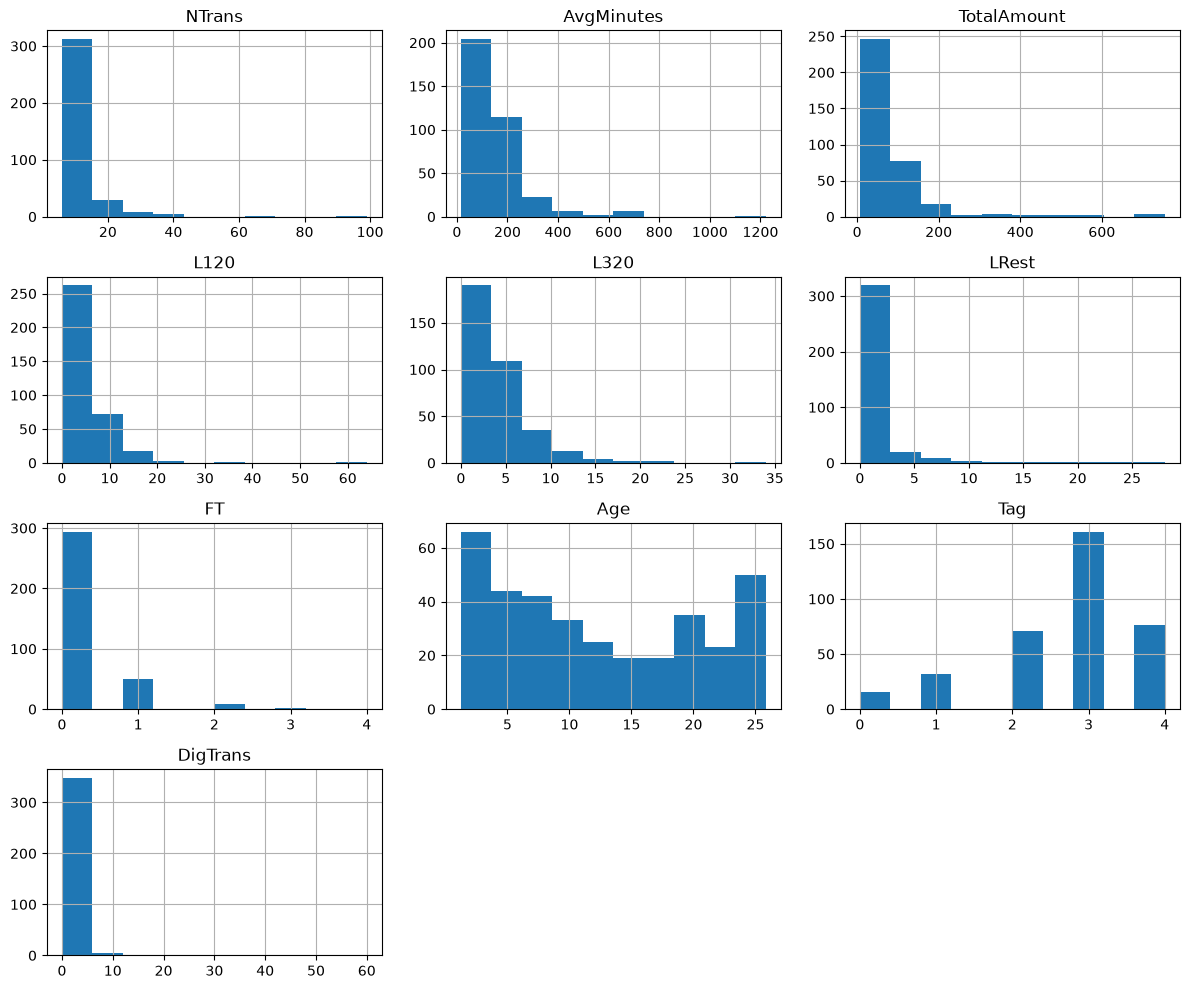

In [18]:
fig, ax = plt.subplots(figsize=(12, 10))

# Removing the customer's id before plotting the distributions
df.drop('plate', axis=1).hist(ax=ax)

plt.tight_layout()
plt.show()

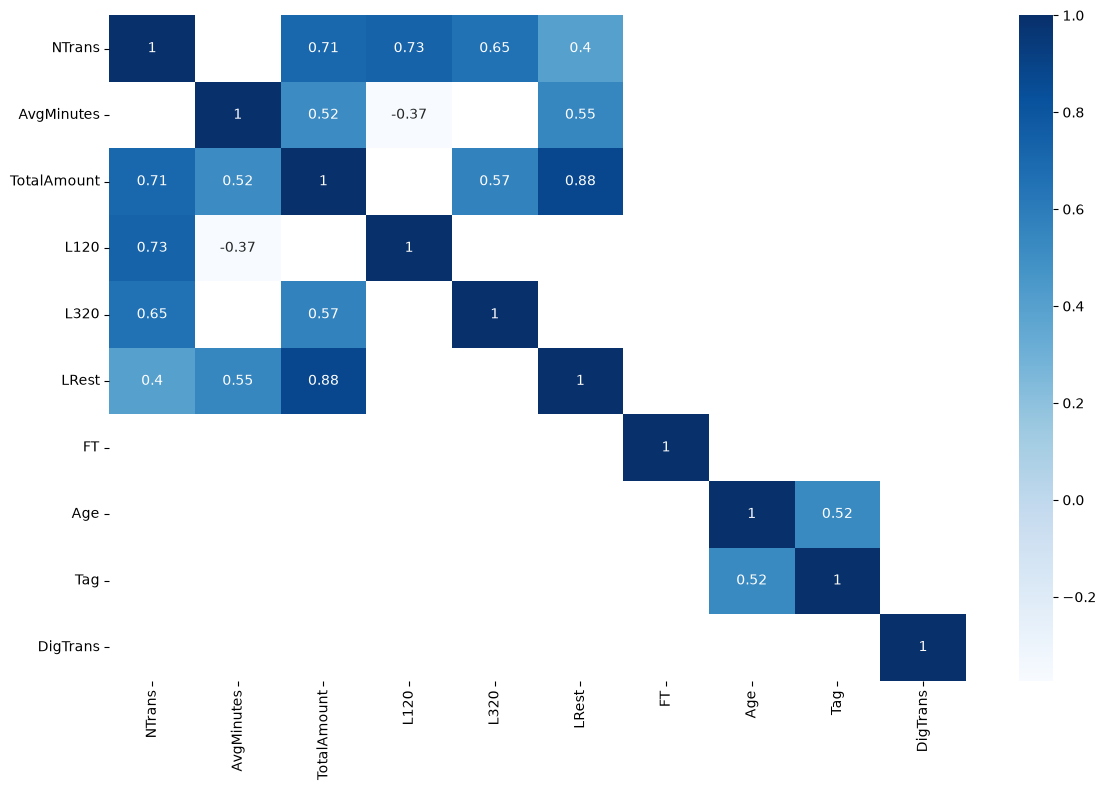

In [19]:
correlations = df.drop('plate', axis=1).corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12,8))
sns.heatmap(correlations[(correlations > 0.30) | (correlations < -0.30)],
            cmap='Blues', annot=True, ax=ax)

plt.tight_layout()
plt.show()

In [20]:
X = df.drop('plate', axis=1)

scaler = StandardScaler()
scaler.fit(X)

X_scaled = scaler.transform(X)

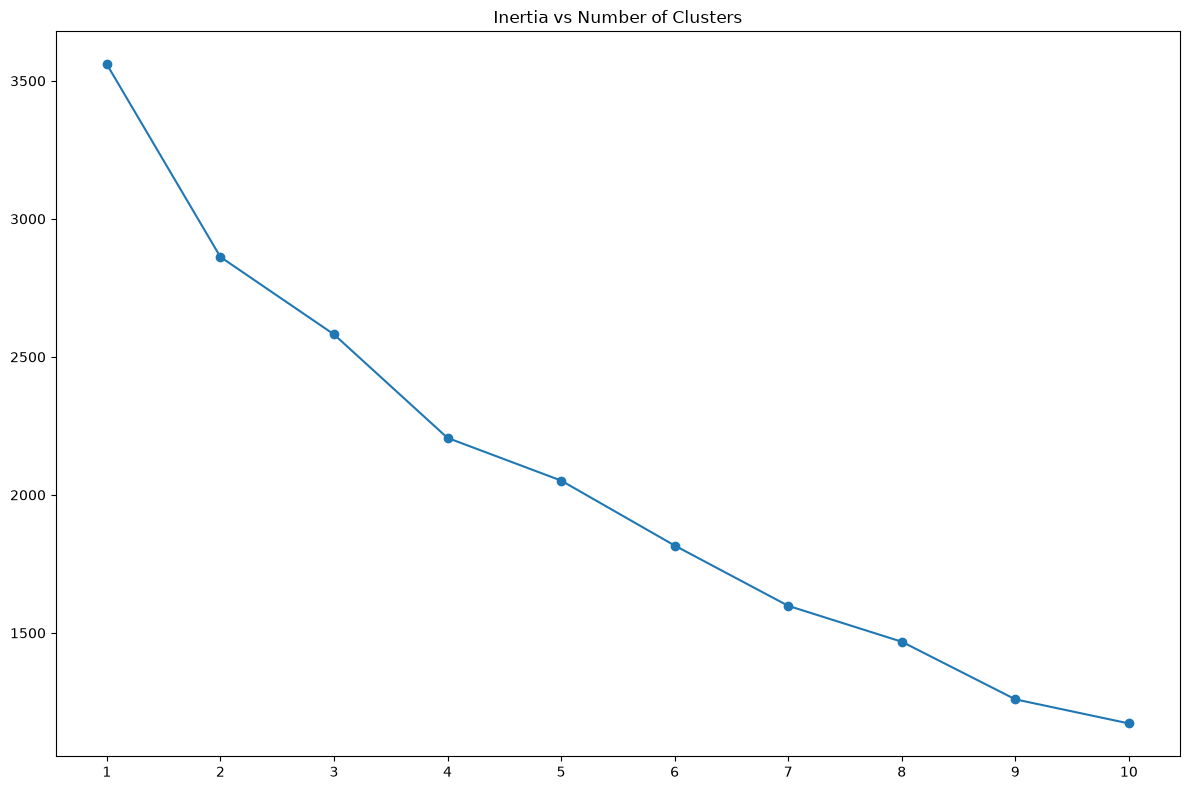

In [21]:
X = pd.DataFrame(X_scaled)
inertias = []

for k in range(1, 11):
    model = KMeans(n_clusters=k)
    y = model.fit_predict(X)
    inertias.append(model.inertia_)

plt.figure(figsize=(12, 8))
plt.plot(range(1, 11), inertias, marker='o')
plt.xticks(ticks=range(1, 11), labels=range(1, 11))
plt.title('Inertia vs Number of Clusters')

plt.tight_layout()
plt.show()

In [22]:
model = KMeans(n_clusters=8)
y = model.fit_predict(X_scaled)

# Adding the cluster assignments to our original dataframe
df['CLUSTER'] = y + 1  # Adding 1 to make clusters 1-based instead of 0-based
# df.head()

In [23]:
df['CLUSTER'].value_counts()

CLUSTER
5    127
1    120
6     70
2     20
8     10
7      6
3      2
4      1
Name: count, dtype: int64

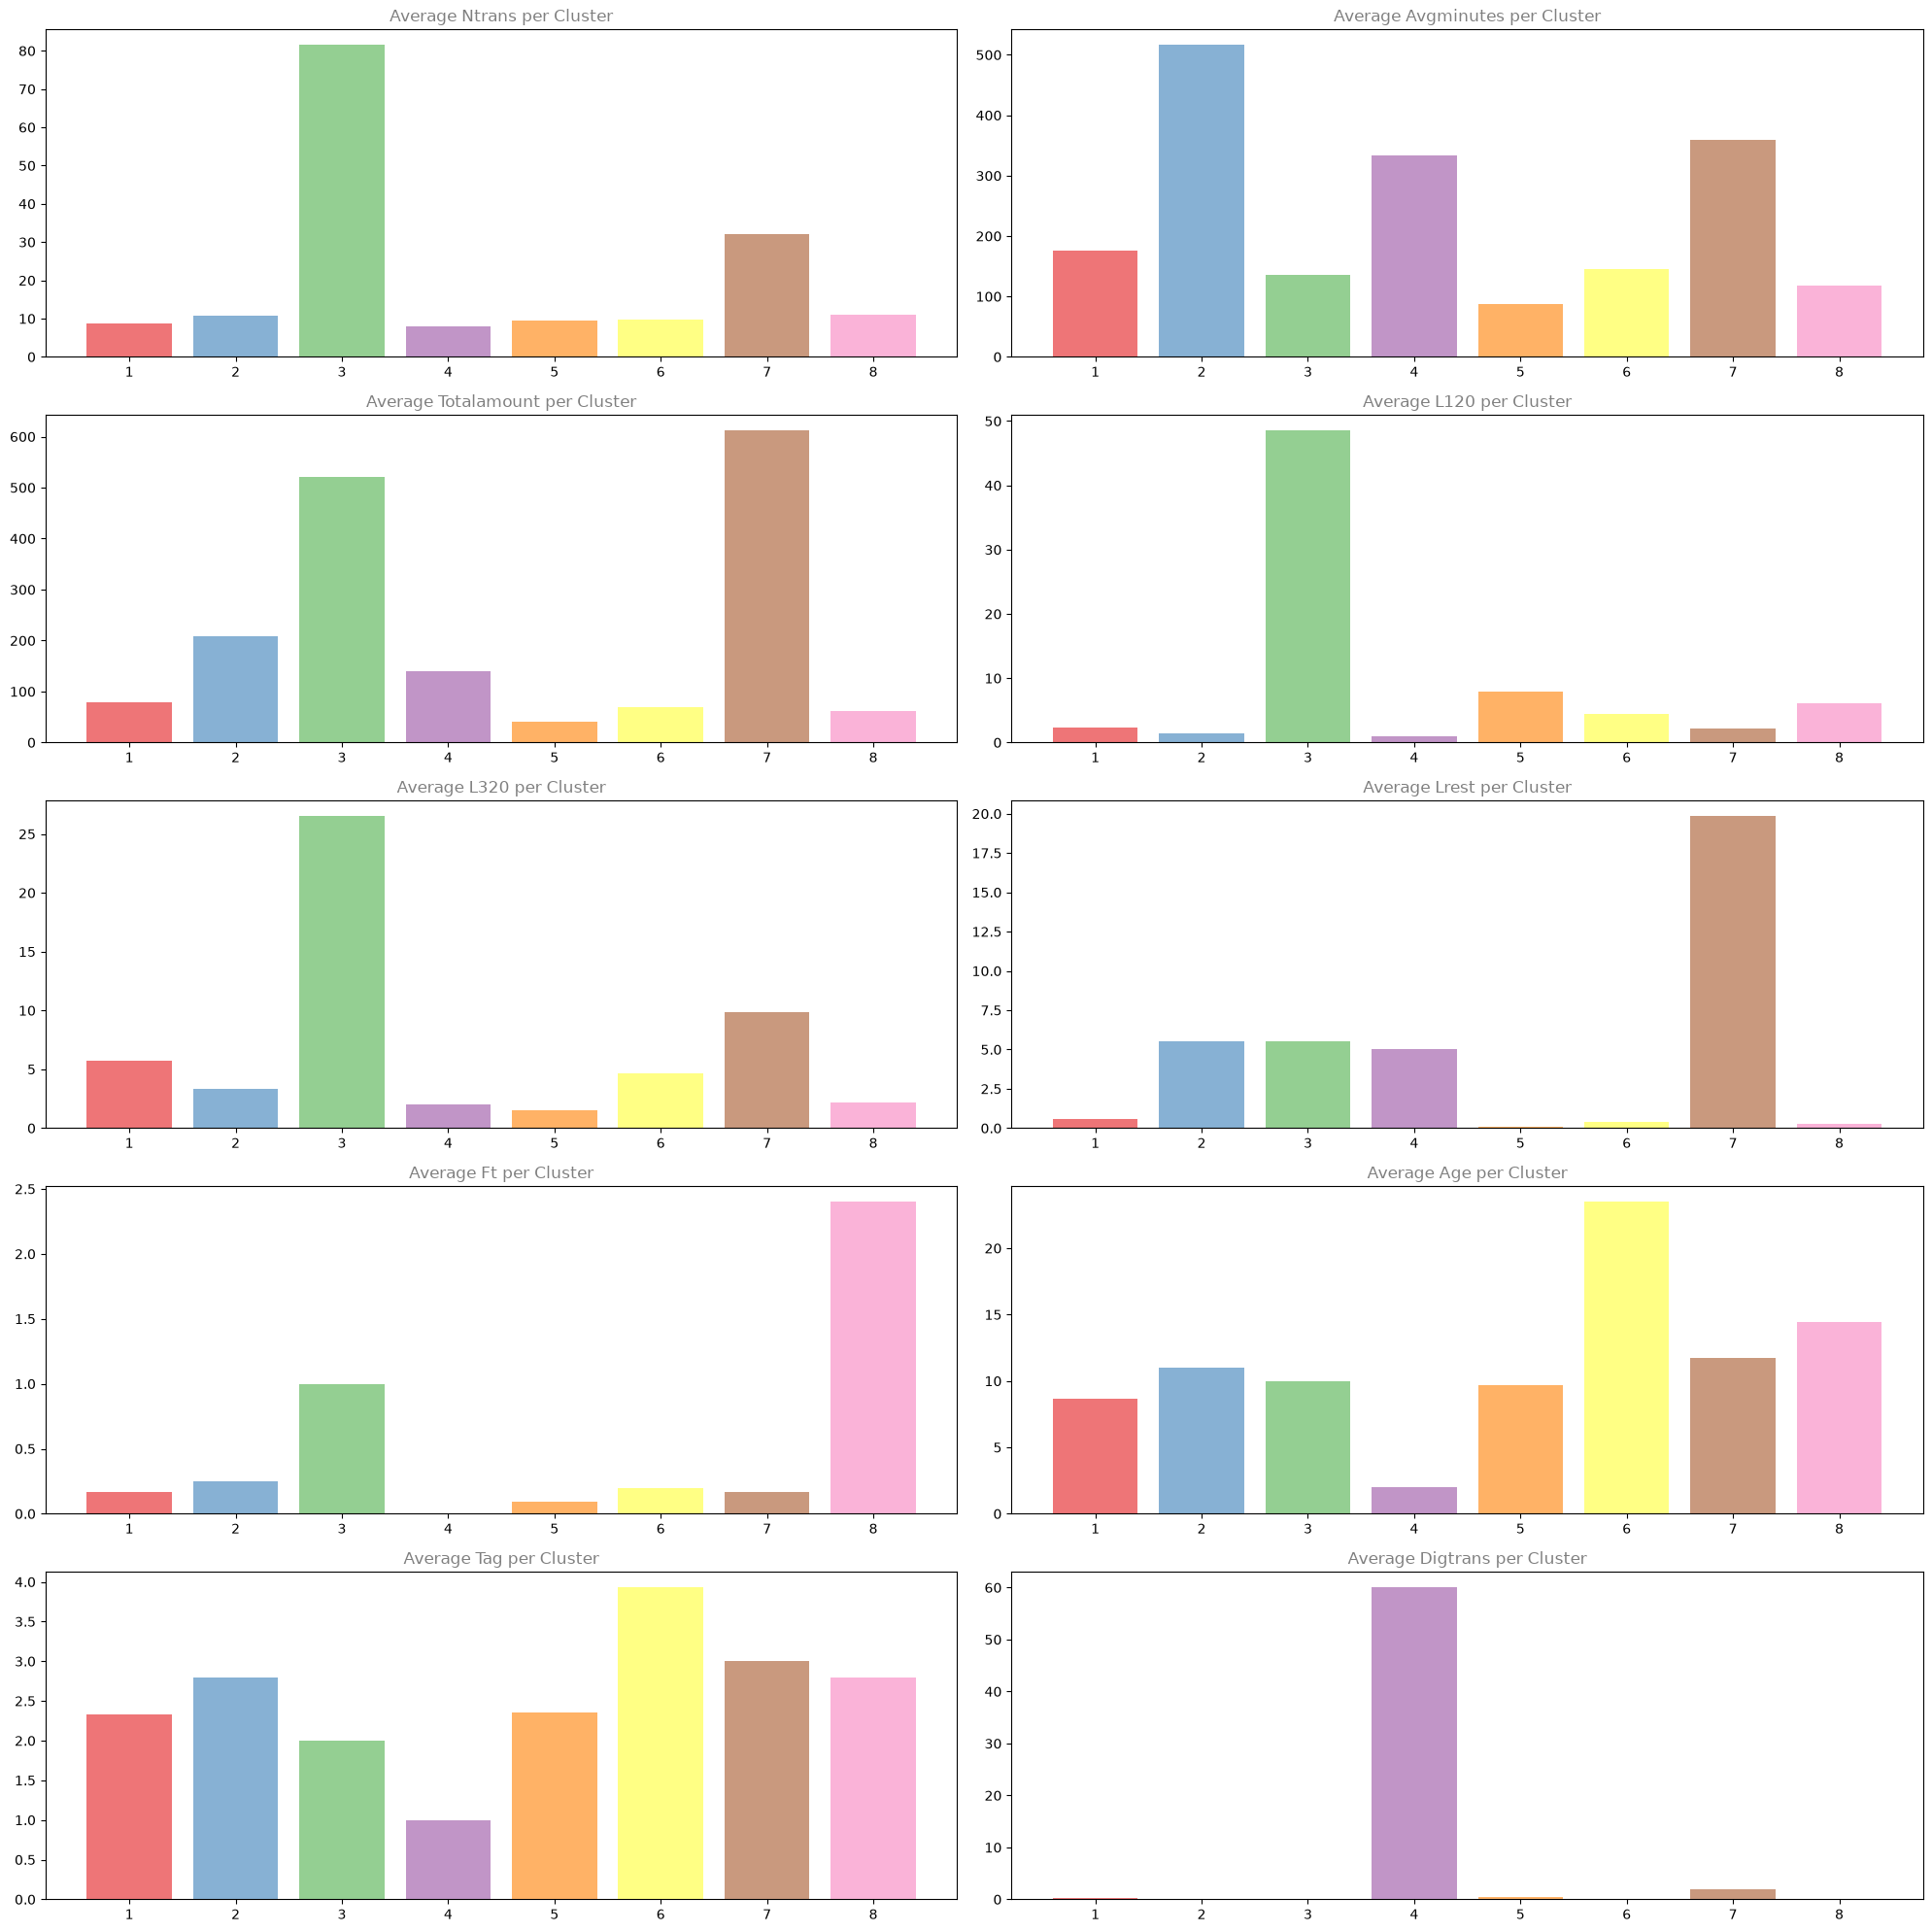

In [24]:
numeric_columns = df.select_dtypes(include=np.number).drop(['CLUSTER'], axis=1).columns

fig = plt.figure(figsize=(20, 20))
for i, column in enumerate(numeric_columns):
    df_plot = df.groupby('CLUSTER')[column].mean()
    ax = fig.add_subplot(5, 2, i+1)
    ax.bar(df_plot.index, df_plot, color=sns.color_palette('Set1'), alpha=0.6)
    ax.set_title(f'Average {column.title()} per Cluster', alpha=0.5)
    ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

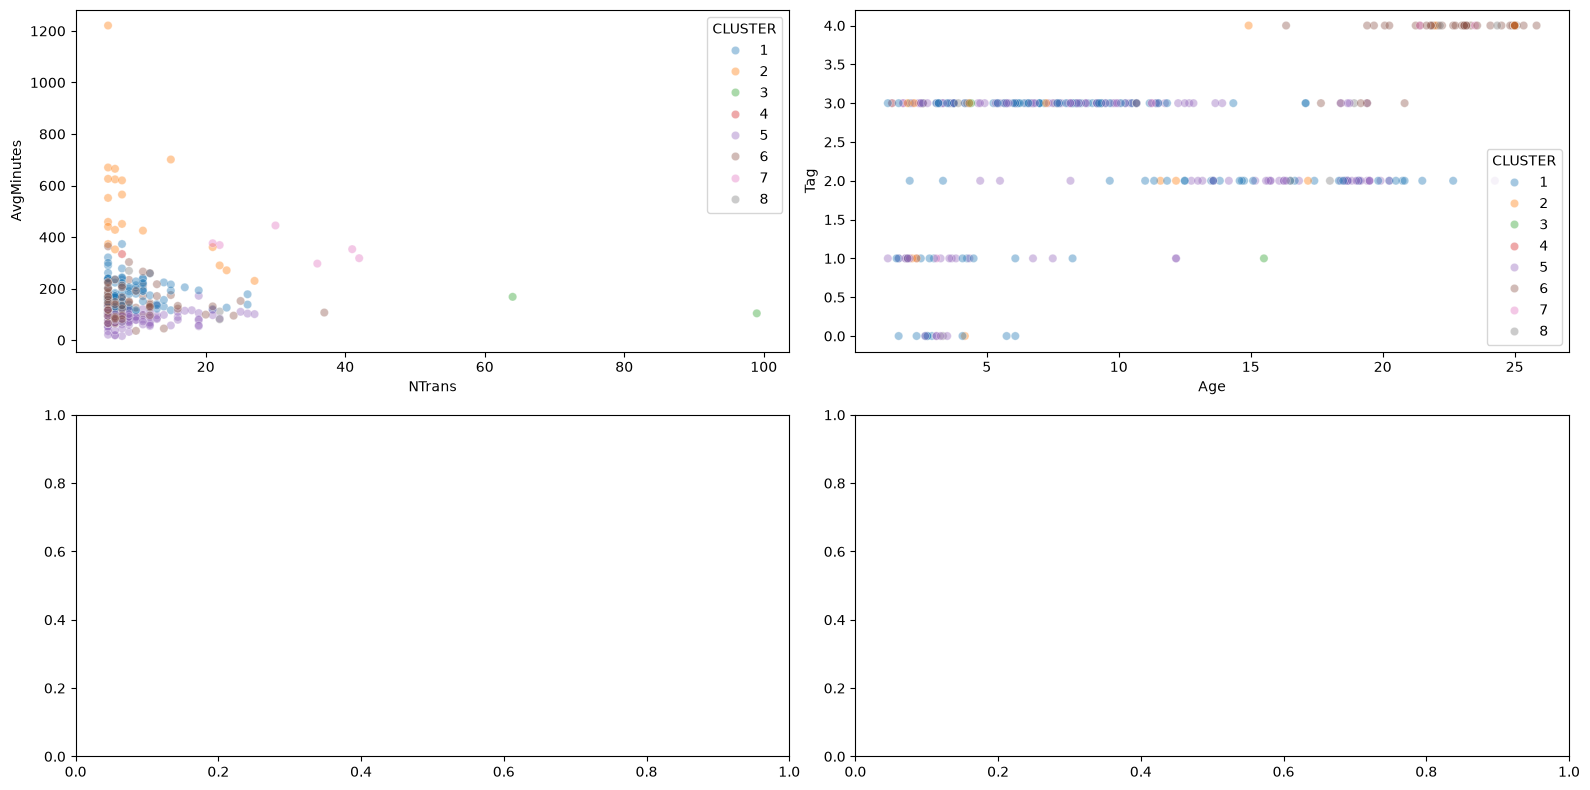

In [25]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 8))
sns.scatterplot(x='NTrans', y='AvgMinutes', hue='CLUSTER', data=df, palette='tab10', alpha=0.4, ax=ax1)
sns.scatterplot(x='Age', y='Tag', hue='CLUSTER', data=df, palette='tab10', alpha=0.4, ax=ax2)

plt.tight_layout()
plt.show()